# Codigo inicial para el analisis del fondo e informacion sobre la imagen tomada de la Raspberry Pi


Hecho por:
*   Agustin Luna Simondi
*   Manuel Davila









# Introducción

## Resumen

Ese codigo representa uno de los varios modulos de la secion de codigo y desarrollo de redes neuronales para el Proyecto Final de Carrera. En esta seccion en particular se busca hacer un analisis exhaustivo del fondo de imagen (que en este caso es la cuerina de color blanca que forma la superficie de la cinta movil) ademas de brindar datos informativos del tipo de imagen obtenidos a traves del uso de la camara 5MP OV5647 v1.3 tambien de Raspbery Pi.

# Librerias y conexión al Drive




In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
import os
from tqdm import tqdm

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
main_path = '/content/drive/MyDrive/Proyecto Final de Carrera/Data-sets'


Importacion de la imagen de fondo

In [7]:
fondos = main_path + '/Fondo'


# Carga de imagenes y analisis de las mismas

In [8]:
contador = sum(1 for archivo in os.listdir(fondos) )
print(f"Cantidad de imágenes: {contador}")


Cantidad de imágenes: 9


Dimension de la imagen obtenida mediante la camara de la raspberry pi

In [9]:
primera_imagen = cv2.imread(fondos + '/fondo_8.jpg')
dimensiones = primera_imagen.shape[:2]
print(f"Dimensiones de la imagen: {dimensiones}")

Dimensiones de la imagen: (256, 256)


El tamano de la imagen es totalmente ajustable pudiendo tener una mayor dimensionalidad o menor , se eligio 480x640 a modo de que el programa pueda correr de manera mas fluida y no haya perdida de fps al visualizar la camara en tiempo real.

### Visualización de las imagenes

Se revisaron todas las imagenes en donde se tiene que aquellas larvas optimas para la infección van del numero 41 al 57 y el resto de las imagenes corresponden a aquellas que son muy jovenes o en estadios ya muy avanzados.

Por lo tanto tenemos 16 imagenes correspondientes a larvas listas para la inyección y otras 64 que no se encuentran en un estadio apropiado.

Otra cosa a notar es la gran dimensionalidad de la imagen lo cual permitira en caso de necesitarlo poder agrandar la imagen observar con mayor detalle las larvas de manera individual.

In [10]:
def plot_imagen_numerada(ruta_carpeta, inicio, fin):
    """
    Muestra las imágenes de larvas dentro de un rango específico.

    Parámetros:
    - ruta_carpeta: Ruta de la carpeta donde están las imágenes.
    - inicio: Número inicial del rango de larvas.
    - fin: Número final del rango de larvas.
    """
    # Obtener todas las imágenes en la carpeta con formato "larvas_n"
    imagenes = [f for f in os.listdir(ruta_carpeta) if f.startswith("larvas_") and f.endswith(('.jpg', '.png', '.jpeg'))]

    # Filtrar imágenes por rango
    imagenes_en_rango = [
        img for img in imagenes
        if inicio <= int(img.split('_')[1].split('.')[0]) <= fin
    ]

    # Ordenarlas por número
    imagenes_en_rango.sort(key=lambda x: int(x.split('_')[1].split('.')[0]))

    if not imagenes_en_rango:
        print(f"No se encontraron imágenes en el rango {inicio} al {fin}.")
        return

    # Plotear las imágenes
    filas = (len(imagenes_en_rango)) # Máximo 5 imágenes por fila
    plt.figure(figsize=(100,  15* filas))
    plt.suptitle(f"Larvas del rango {inicio} al {fin}", fontsize=16)

    for i, img_name in enumerate(imagenes_en_rango):
        img_path = os.path.join(ruta_carpeta, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB

        # Crear subplot para cada imagen
        plt.subplot(filas, 1, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_name, fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Ajustar layout para el título principal
    plt.show()

In [11]:
def plot_fondo_numerada(ruta_carpeta, inicio, fin):
    """
    Muestra las imágenes de larvas dentro de un rango específico.

    Parámetros:
    - ruta_carpeta: Ruta de la carpeta donde están las imágenes.
    - inicio: Número inicial del rango de larvas.
    - fin: Número final del rango de larvas.
    """
    # Obtener todas las imágenes en la carpeta con formato "larvas_n"
    imagenes = [f for f in os.listdir(ruta_carpeta) if f.startswith("fondo_") and f.endswith(('.jpg', '.png', '.jpeg'))]

    # Filtrar imágenes por rango
    imagenes_en_rango = [
        img for img in imagenes
        if inicio <= int(img.split('_')[1].split('.')[0]) <= fin
    ]

    # Ordenarlas por número
    imagenes_en_rango.sort(key=lambda x: int(x.split('_')[1].split('.')[0]))

    if not imagenes_en_rango:
        print(f"No se encontraron imágenes en el rango {inicio} al {fin}.")
        return

    # Plotear las imágenes
    filas = (len(imagenes_en_rango)) # Máximo 5 imágenes por fila
    plt.figure(figsize=(100,  15* filas))
    plt.suptitle(f"Fondo del rango {inicio} al {fin}", fontsize=16)

    for i, img_name in enumerate(imagenes_en_rango):
        img_path = os.path.join(ruta_carpeta, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB

        # Crear subplot para cada imagen
        plt.subplot(filas, 1, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_name, fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Ajustar layout para el título principal
    plt.show()

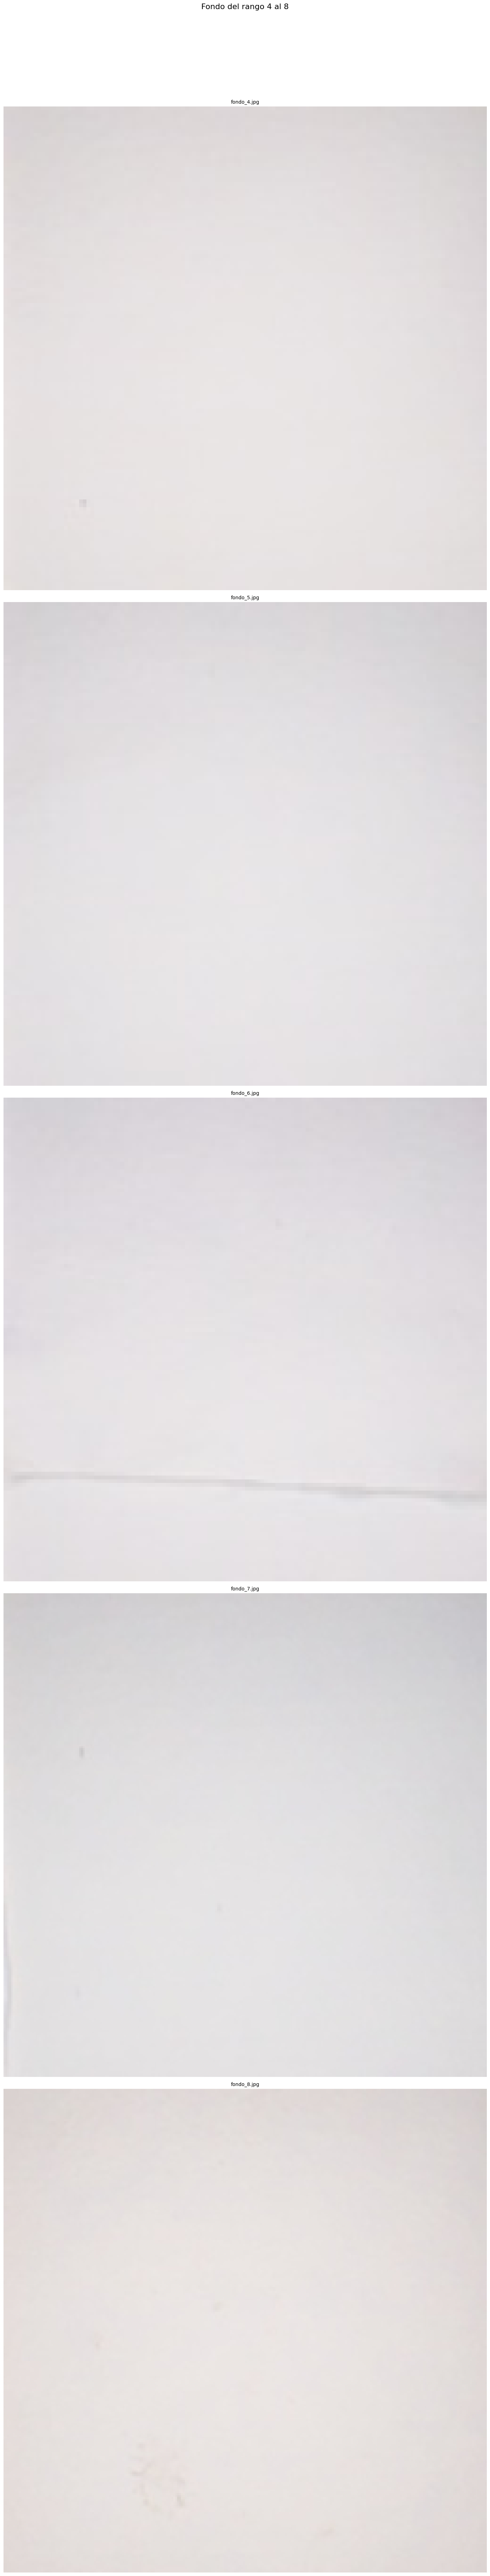

In [12]:
inicio = 4
fin = 8
plot_fondo_numerada (fondos, inicio, fin)

El fondo elegido para la cinta donde se colocaran las larvas son blancas para asi poder reslatar los colores de las larvas (que tienen tonalidades verdes y negras). Podemos notar que el fondo es bastante homogeneo aunque hay zonas que parecieran ser menos claras.
Para iluminar la cinta se utilizo un anillo LED colocado de manera perpenidcular por encima de la cinta a modo de no generar sombras , ademas del hecho que no hay otra fuente de luz y el sistema se encuentra inmerso dentro de un caja totalmente a oscuras.
Por lo tanto las diferencias de la homogeniedad del fondo no se debe a sombrar sino que podria deberse a manchas en la cinta en si dado a su uso u otros motivos durante la confeccion de la cinta.

## Analisis del fondo/ruido

In [13]:
def plot_1(imagen, t = "Imagen", color = 'gray'):
  plt.figure(figsize=(7, 7))
  plt.imshow(imagen, vmin=0, vmax=255, cmap = color)
  plt.title(t, fontsize=15)
  plt.axis("off")
  plt.show()
  return

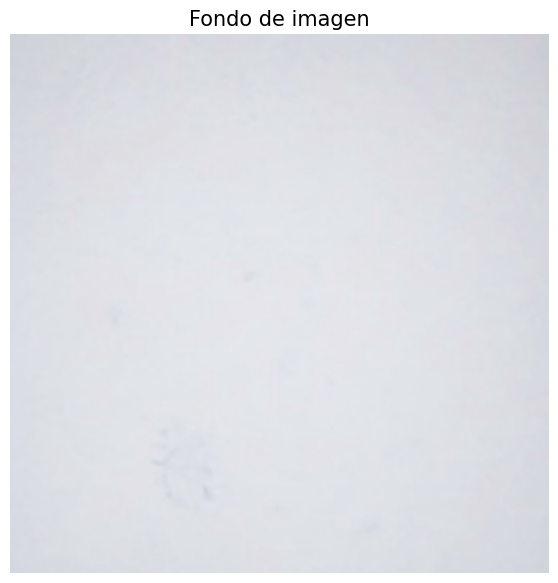

In [14]:
img_path = '/content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Fondo/fondo_8.jpg'
fondo = cv2.imread(img_path)

plot_1(fondo, "Fondo de imagen")

Elegimos la imagen del fondo 2 en un principio dado a que es la que se obtuvo con menor cantidad de inhomogeniedades a la vista y que ademas dado a que era el que menor desvio standar de la intensidad de pixeles.

In [15]:
def display_rgb_channels(image):
    """
    Muestra los canales R, G y B de una imagen RGB en una fila con barras de color.
    También incluye la imagen RGB combinada como una cuarta columna.
    """
    channels = cv2.split(image)  # Divide en R, G, B
    titles = ['Red Channel', 'Green Channel', 'Blue Channel', 'Combined RGB']
    colormaps = ['Reds', 'Greens', 'Blues', None]  # None para la imagen combinada

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    for i, (title, cmap) in enumerate(zip(titles, colormaps)):
        ax = axs[i]
        if i < 3:
            # Mostrar los canales individuales
            im = ax.imshow(channels[i], cmap=cmap)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            # Mostrar la imagen combinada
            im = ax.imshow(image)

        ax.set_title(title)
        ax.axis('off')

    plt.subplots_adjust(wspace=0.1)  # Reduce el espacio entre columnas
    plt.tight_layout()
    plt.show()

### Histograma de intensidades y reconstruccion de distribución normal



In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_background_noise(background_image):
    """
    Analiza el ruido de fondo en una imagen generando un histograma de las intensidades de los píxeles.

    Parámetros:
    - background_image: Imagen en escala de grises o en formato RGB.

    Muestra:
    - Un histograma de intensidades de los píxeles del fondo.
    """
    # Convertir a escala de grises si la imagen está en RGB
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Calcular el histograma de intensidades
    histogram = cv2.calcHist([background_gray], [0], None, [256], [0, 256])

    # Normalizar el histograma para mejor visualización
    histogram = histogram / np.sum(histogram)

    # Graficar el histograma
    plt.figure(figsize=(10, 6))
    plt.plot(histogram, color='blue')
    plt.title("Histograma de Intensidades del Fondo")
    plt.xlabel("Intensidad de Píxel (0-255)")
    plt.ylabel("Frecuencia Normalizada")
    plt.grid(alpha=0.4)
    plt.show()

    # Calcular estadísticas del ruido
    mean_intensity = np.mean(background_gray)
    std_intensity = np.std(background_gray)

    print(f"Media de intensidad del fondo: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido): {std_intensity:.2f}")


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_background_noise(background_image):
    """
    Analiza el ruido de fondo en una imagen generando un histograma de las intensidades de los píxeles.

    Parámetros:
    - background_image: Imagen en escala de grises o en formato RGB.

    Muestra:
    - Un histograma de intensidades de los píxeles del fondo con la intensidad de mayor frecuencia marcada.
    """
    # Convertir a escala de grises si la imagen está en RGB
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Calcular el histograma de intensidades
    histogram = cv2.calcHist([background_gray], [0], None, [256], [0, 256])

    # Normalizar el histograma para mejor visualización
    histogram = histogram / np.sum(histogram)

    # Encontrar la intensidad con mayor frecuencia normalizada
    max_freq_index = np.argmax(histogram)
    max_freq_value = histogram[max_freq_index][0]

    # Graficar el histograma
    plt.figure(figsize=(10, 6))
    plt.plot(histogram, color='blue', label='Histograma')

    # Marcar la intensidad con mayor frecuencia
    plt.axvline(x=max_freq_index, color='red', linestyle='--', linewidth=2,
                label=f'Máxima frecuencia (Intensidad: {max_freq_index})')
    plt.scatter(max_freq_index, max_freq_value, color='red', s=100, zorder=5)

    plt.title("Histograma de Intensidades del Fondo")
    plt.xlabel("Intensidad de Píxel (0-255)")
    plt.ylabel("Frecuencia Normalizada")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()

    # Calcular estadísticas del ruido
    mean_intensity = np.mean(background_gray)
    std_intensity = np.std(background_gray)

    print(f"Media de intensidad del fondo: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido): {std_intensity:.2f}")
    print(f"Intensidad con mayor frecuencia normalizada: {max_freq_index} (frecuencia: {max_freq_value:.4f})")



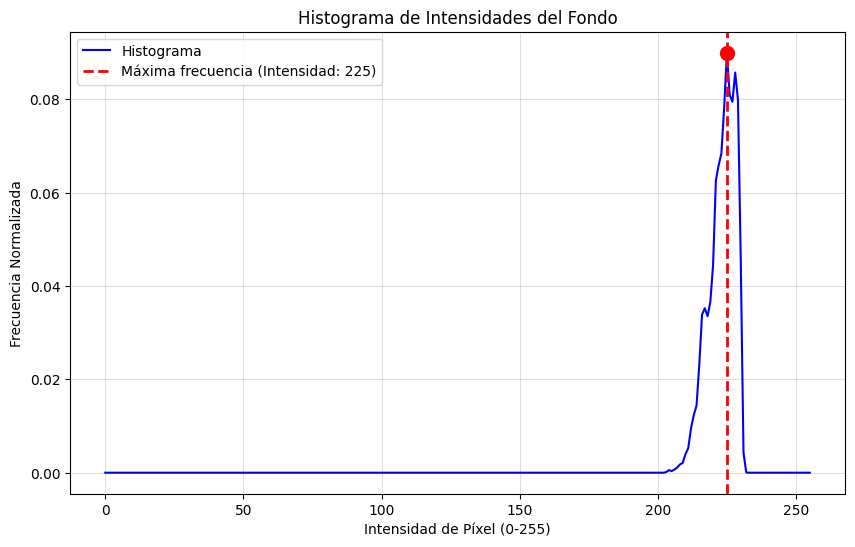

Media de intensidad del fondo: 223.23
Desviación estándar del fondo (ruido): 4.81
Intensidad con mayor frecuencia normalizada: 225 (frecuencia: 0.0900)


In [18]:
analyze_background_noise(fondo)

Observando los parametros , en un principio hay un ruido muy bajo ya que podemos  ver que la intensidad de pixel se encuentra bien concentrado y con un muy bajo desvio.
Si hubiera que asociar al ruido con algun tipo se lo podria relacionar con una distibución gaussiano/normal ya que no vemos indicios de  algún otro tipo ruido.

Además hay que tomar en consideración que el fondo analizado no es un  fondo homogéneo o perfecto sino que corresponde a una cinta de cuerina blanca  la cual podria tener cambios de tonalidades sutiles lo que produce que haya una distribución de la intensidad.

In [19]:
from scipy.stats import norm

def fit_noise_distribution(background_image):
    """
    Ajusta la distribución de las intensidades del ruido a una distribución normal (Gaussiana).
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Obtener las intensidades de los píxeles
    intensities = background_gray.flatten()

    # Ajustar a una distribución normal
    mean, std = norm.fit(intensities)

    # Crear un histograma de las intensidades
    plt.figure(figsize=(10, 6))
    plt.hist(intensities, bins=50, density=True, alpha=0.6, color='blue', label="Datos reales")

    # Graficar la distribución ajustada
    x = np.linspace(min(intensities), max(intensities), 100)
    plt.plot(x, norm.pdf(x, mean, std), 'r-', lw=2, label=f"Normal Ajustada (μ={mean:.2f}, σ={std:.2f})")

    plt.title("Ajuste de Distribución del Ruido")
    plt.xlabel("Intensidad de Píxel")
    plt.ylabel("Densidad de Probabilidad")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()




In [ ]:
 fit_noise_distribution(fondo)

La posible distribución normal del ruido se visualiza en la imagen dando una explicación al bajo valor del desvio. Vemos que se encuentra el balor concentrado en 208 y que no hay una larga extensión en las intensidades sino que ya fuera de un rango se anula  rapidamente.

## Analisis estadistico


In [20]:
from scipy.stats import normaltest

def test_noise_normality(background_image):
    """
    Realiza un test de normalidad sobre las intensidades de píxeles de la imagen de fondo.

    Parámetros:
    - background_image: Imagen en escala de grises o en formato RGB.

    Imprime:
    - El resultado del test de normalidad (estadístico y valor p).
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Obtener las intensidades de los píxeles
    intensities = background_gray.flatten()

    # Realizar el test de normalidad (D'Agostino y Pearson's test)
    statistic, p_value = normaltest(intensities)

    print(f"Estadístico del test de normalidad: {statistic:.4f}")
    print(f"Valor p del test de normalidad: {p_value:.4f}")

    if p_value > 0.05:
        print("El valor p es mayor que 0.05, lo que sugiere que los datos podrían provenir de una distribución normal.")
    else:
        print("El valor p es menor o igual que 0.05, lo que sugiere que los datos no siguen una distribución normal.")

In [ ]:
test_noise_normality(fondo)

--- Estadísticos ---
Media: 224.50
Desviación estándar: 4.60
Mediana: 225.00
Moda: 226

--- Tests de normalidad ---
Shapiro-Wilk: stat=0.9493, p=0.0000
D'Agostino-Pearson: stat=5159.1464, p=0.0000
Kolmogorov-Smirnov: stat=0.1063, p=0.0000


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 65536.
  res = hypotest_fun_out(*samples, **kwds)


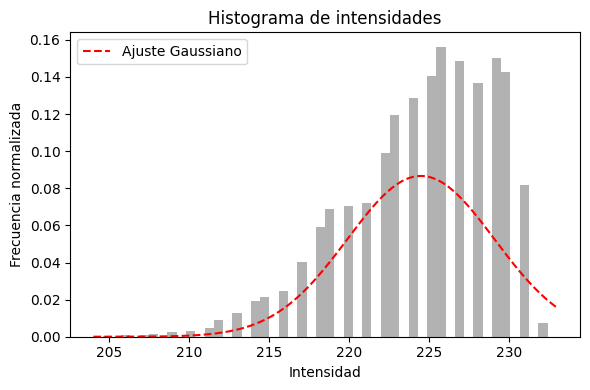

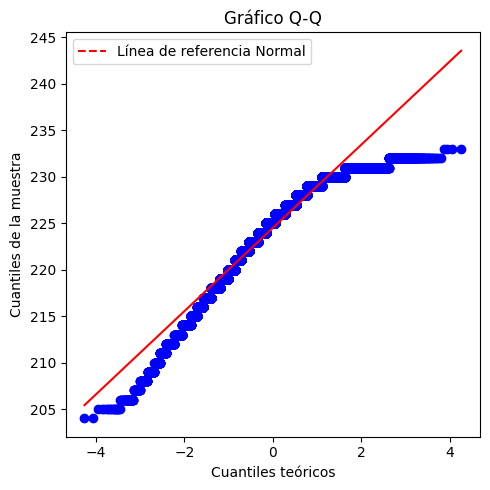

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import normaltest, shapiro, kstest, norm
from statistics import mode

def analyze_noise(image_path):
    """
    Analiza el ruido de fondo de una única imagen (ej. 256x256).
    Aplica tests de normalidad y genera gráficos.

    Parámetros:
    - image_path: ruta de la imagen de fondo.
    """
    # Leer imagen
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("No se pudo cargar la imagen. Revisa la ruta.")

    intensities = img.flatten()

    # Estadísticos básicos
    mean_val = np.mean(intensities)
    std_val = np.std(intensities)
    median_val = np.median(intensities)
    try:
        mode_val = mode(intensities)  # puede fallar si hay múltiples modas
    except:
        mode_val = "Múltiples valores"

    print("--- Estadísticos ---")
    print(f"Media: {mean_val:.2f}")
    print(f"Desviación estándar: {std_val:.2f}")
    print(f"Mediana: {median_val:.2f}")
    print(f"Moda: {mode_val}")

    # Tests de normalidad
    print("\n--- Tests de normalidad ---")
    stat1, p1 = shapiro(intensities)
    print(f"Shapiro-Wilk: stat={stat1:.4f}, p={p1:.4f}")

    stat2, p2 = normaltest(intensities)
    print(f"D'Agostino-Pearson: stat={stat2:.4f}, p={p2:.4f}")

    stat3, p3 = kstest(intensities, 'norm', args=(mean_val, std_val))
    print(f"Kolmogorov-Smirnov: stat={stat3:.4f}, p={p3:.4f}")

    # Histograma con ajuste gaussiano
    plt.figure(figsize=(6,4))
    plt.hist(intensities, bins=50, density=True, alpha=0.6, color='gray')
    x = np.linspace(min(intensities), max(intensities), 200)
    plt.plot(x, norm.pdf(x, mean_val, std_val), 'r--', label="Ajuste Gaussiano")
    plt.xlabel("Intensidad")
    plt.ylabel("Frecuencia normalizada")
    plt.title("Histograma de intensidades")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Q-Q plot
    from scipy import stats
    plt.figure(figsize=(5,5))
    stats.probplot(intensities, dist="norm", plot=plt)
    plt.title("Gráfico Q-Q")
    plt.xlabel("Cuantiles teóricos")
    plt.ylabel("Cuantiles de la muestra")
    # Add label to the red line
    plt.plot([], [], color='red', linestyle='--', label='Línea de referencia Normal')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
analyze_noise('/content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Fondo/fondo_8.jpg')

### Posibles zonas de "ruido"

In [22]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def analyze_noise_map(background_image, circle_size=4000):
    """
    Genera un mapa de diferencias absolutas para analizar las variaciones de ruido
    y señala el punto con mayor diferencia en la imagen original.

    Parameters:
    - background_image: Imagen del fondo (puede ser en color o escala de grises).
    - circle_size: Tamaño del círculo que destaca el punto con mayor diferencia.
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Calcular la media del fondo
    mean_intensity = np.mean(background_gray)

    # Crear un mapa de ruido (diferencia absoluta con la media)
    noise_map = np.abs(background_gray - mean_intensity)

    # Encontrar el punto con la máxima diferencia
    max_difference = np.max(noise_map)
    max_diff_point = np.unravel_index(np.argmax(noise_map), noise_map.shape)

    # Mostrar los resultados
    fig = plt.figure(figsize=(16, 6))

    # Subplot 1: Mapa de ruido
    plt.subplot(1, 2, 1)
    plt.imshow(noise_map, cmap='hot')
    plt.colorbar(label="Diferencia Absoluta")
    plt.title("Mapa de Diferencia Absoluta")
    plt.axis("off")

    # Subplot 2: Imagen original con punto destacado
    plt.subplot(1, 2, 2)
    plt.imshow(background_gray, cmap='gray')
    plt.title("Zona con Mayor Diferencia")
    plt.axis("off")

    # Dibujar un círculo en el punto con mayor diferencia
    plt.scatter(
        max_diff_point[1], max_diff_point[0],
        s=circle_size,
        edgecolor='red',
        facecolors='none',
        linewidth=1.5
    )

    # Ajustar el espaciado entre subplots
    plt.subplots_adjust(left=0.08, right=0.85, wspace=0.15)

    # Agregar label vertical indicando el espacio de color
    fig.text(0.04, 0.5, 'Analisis en Espacio de Escala de Grises', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    # Imprimir estadísticas
    print(f"Media del fondo: {mean_intensity:.2f}")
    print(f"Máxima diferencia en el ruido: {max_difference:.2f}")
    print(f"Coordenadas del punto de mayor diferencia: {max_diff_point}")

def analyze_noise_map_color(background_image, circle_size=4000):
    """
    Genera un mapa de diferencias absolutas para analizar las variaciones de ruido
    en la imagen original a color y señala el punto con mayor diferencia.

    Parameters:
    - background_image: Imagen del fondo (en color, formato RGB).
    - circle_size: Tamaño del círculo que destaca el punto con mayor diferencia.
    """
    # Calcular la media de intensidad para cada canal (R, G, B)
    mean_intensity = np.mean(background_image, axis=(0, 1))

    # Crear un mapa de ruido (diferencia absoluta para cada canal)
    noise_map = np.abs(background_image - mean_intensity)

    # Combinar el ruido de los canales en un único mapa (norma L2)
    combined_noise_map = np.sqrt(np.sum(noise_map**2, axis=-1))

    # Encontrar el punto con la máxima diferencia
    max_difference = np.max(combined_noise_map)
    max_diff_point = np.unravel_index(np.argmax(combined_noise_map), combined_noise_map.shape)

    # Mostrar los resultados
    fig = plt.figure(figsize=(16, 6))

    # Subplot 1: Mapa de ruido
    plt.subplot(1, 2, 1)
    plt.imshow(combined_noise_map, cmap='hot')
    plt.colorbar(label="Diferencia Absoluta")
    plt.title("Mapa de Diferencia Absoluta")
    plt.axis("off")

    # Subplot 2: Imagen original con punto destacado
    plt.subplot(1, 2, 2)
    plt.imshow(background_image)
    plt.title("Zona con Mayor Diferencia")
    plt.axis("off")

    # Dibujar un círculo en el punto con mayor diferencia
    plt.scatter(
        max_diff_point[1], max_diff_point[0],
        s=circle_size,
        edgecolor='red',
        facecolors='none',
        linewidth=1.5
    )
    plt.subplots_adjust(left=0.08, right=0.85, wspace=0.15)

    # Agregar label vertical indicando el espacio de color
    fig.text(0.04, 0.5, 'Analaisis en Espacio RGB (Original)', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    # Imprimir estadísticas
    print(f"Media del fondo (R, G, B): {mean_intensity}")
    print(f"Máxima diferencia en el ruido: {max_difference:.2f}")
    print(f"Coordenadas del punto de mayor diferencia: {max_diff_point}")

In [ ]:
analyze_noise_map(fondo)
analyze_noise_map_color(fondo)

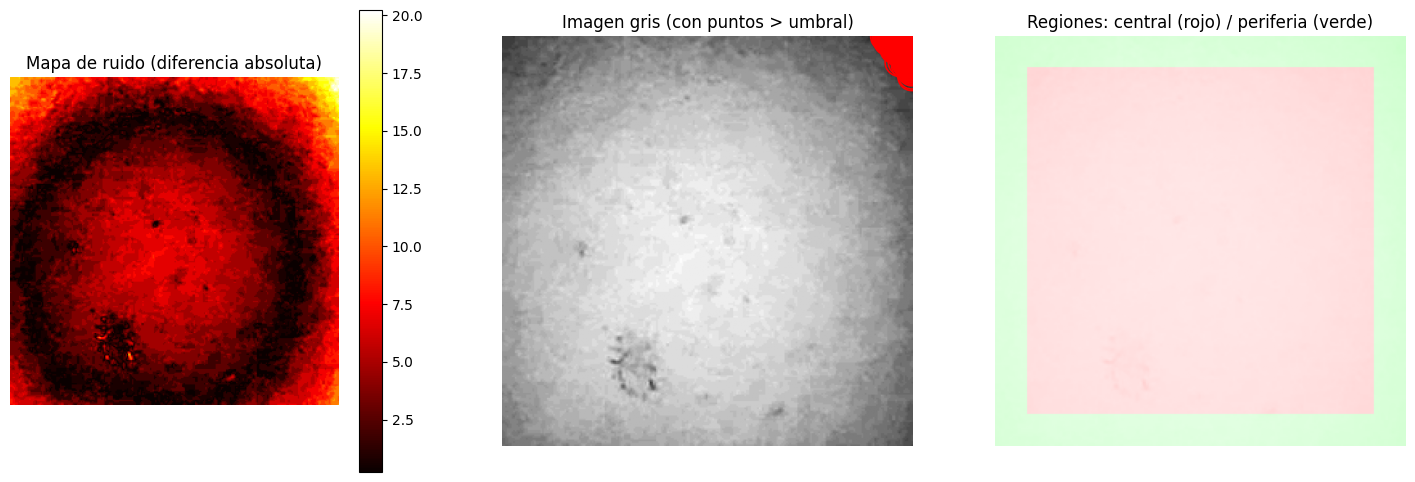

,n,mean,median,std,shapiro_p,dagostino_p,ks_p
label,,,,,,,
global,65536,3.909410,3.766052,2.795495,1.614226e-44,0.000000e+00,0.000000e+00
central,46656,3.380598,3.233948,2.063533,6.939125e-37,0.000000e+00,0.000000e+00
periphery,18880,5.216204,5.233948,3.769043,3.316093e-40,2.969701e-282,8.801829e-210


,n,mean,median,std,shapiro_p,dagostino_p,ks_p,levene_stat,levene_p,cohens_d
label,,,,,,,,,,
comparisons,,,,,,,,10941.901488,0.0,-0.687737


Interpretación rápida:
- Media fondo: 223.23
- Máx diferencia: 20.23, umbral usado: 16.19, puntos > umbral: 185
- Levene stat=10941.901, p=0.0000 -> p<0.05 indica varianzas significativamente distintas
- Cohen's d (central vs periphery) = -0.688 (0.2 small, 0.5 medium, 0.8 large)


In [23]:
# Código para Colab: tests estadísticos y análisis del mapa de diferencia absoluta
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

def compute_noise_map_gray(img_gray):
    mean_intensity = np.mean(img_gray)
    noise_map = np.abs(img_gray - mean_intensity).astype(np.float32)
    return noise_map, mean_intensity

def region_masks(shape, center_frac=0.5, border_margin=10):
    """Mask central rectangle vs peripheral area.
       center_frac: fracción (0..1) del ancho/alto que ocupa la región central.
       border_margin: píxeles a excluir en el borde si querés evitar artefactos extremos.
    """
    h, w = shape
    cx, cy = w//2, h//2
    half_w = int((w * center_frac)/2)
    half_h = int((h * center_frac)/2)
    central = np.zeros((h,w), dtype=bool)
    central[cy-half_h:cy+half_h, cx-half_w:cx+half_w] = True

    periphery = np.ones((h,w), dtype=bool)
    periphery[border_margin:h-border_margin, border_margin:w-border_margin] = False
    # alternative: periphery as everything outside central:
    periphery = ~central
    return central, periphery

def summary_and_tests(noise_map, mask=None, label="all"):
    # select samples
    if mask is None:
        samples = noise_map.ravel()
    else:
        samples = noise_map[mask]
    samples = samples.astype(np.float64)
    # basic stats
    mean = np.mean(samples)
    median = np.median(samples)
    std = np.std(samples, ddof=1)
    n = samples.size
    # normality tests
    # For large n, Shapiro can be slow; D'Agostino is ok
    shapiro_p = np.nan
    try:
        if n <= 5000:
            shapiro_p = stats.shapiro(samples)[1]
        else:
            # sample a subset for Shapiro if too grande
            shapiro_p = stats.shapiro(np.random.choice(samples, 5000, replace=False))[1]
    except Exception as e:
        shapiro_p = np.nan

    dagostino_p = np.nan
    try:
        dagostino_p = stats.normaltest(samples)[1]
    except Exception:
        dagostino_p = np.nan

    # Kolmogorov-Smirnov against normal with sample mean/std
    try:
        ks_stat, ks_p = stats.kstest(samples, 'norm', args=(mean, std))
    except Exception:
        ks_stat, ks_p = np.nan, np.nan

    return {
        "label": label,
        "n": int(n),
        "mean": float(mean),
        "median": float(median),
        "std": float(std),
        "shapiro_p": float(shapiro_p) if not np.isnan(shapiro_p) else np.nan,
        "dagostino_p": float(dagostino_p) if not np.isnan(dagostino_p) else np.nan,
        "ks_p": float(ks_p) if not np.isnan(ks_p) else np.nan
    }

def levene_test(noise_map, mask1, mask2):
    s1 = noise_map[mask1].ravel()
    s2 = noise_map[mask2].ravel()
    stat, p = stats.levene(s1, s2)
    return float(stat), float(p)

def cohens_d(a, b):
    a = a.ravel().astype(np.float64)
    b = b.ravel().astype(np.float64)
    na, nb = a.size, b.size
    ma, mb = a.mean(), b.mean()
    sa2, sb2 = a.var(ddof=1), b.var(ddof=1)
    # pooled std
    pooled = np.sqrt(((na-1)*sa2 + (nb-1)*sb2) / (na+nb-2))
    if pooled == 0:
        return np.nan
    return (ma - mb) / pooled

# Función principal que junta todo y dibuja
def analyze_noise_stats_from_image(background_image, center_frac=0.5, threshold_factor=0.8, circle_size=400):
    # convertir a gris si es color
    if background_image.ndim == 3:
        bg_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        bg_gray = background_image.copy()

    noise_map, mean_intensity = compute_noise_map_gray(bg_gray)
    h, w = bg_gray.shape
    central_mask, periphery_mask = region_masks((h,w), center_frac=center_frac)

    # resumen global, central y periphery
    res_all = summary_and_tests(noise_map, None, label="global")
    res_c = summary_and_tests(noise_map, central_mask, label="central")
    res_p = summary_and_tests(noise_map, periphery_mask, label="periphery")

    # Levene (varianzas)
    levene_stat, levene_p = levene_test(noise_map, central_mask, periphery_mask)
    # effect size
    d = cohens_d(noise_map[central_mask], noise_map[periphery_mask])

    # Mostrar mapas y puntos altos (igual que tu función)
    max_difference = np.max(noise_map)
    threshold = threshold_factor * max_difference
    high_diff_points = np.argwhere(noise_map >= threshold)

    plt.figure(figsize=(18,6))
    plt.subplot(1,3,1)
    plt.imshow(noise_map, cmap='hot')
    plt.title("Mapa de ruido (diferencia absoluta)")
    plt.axis('off')
    plt.colorbar()

    plt.subplot(1,3,2)
    plt.imshow(bg_gray, cmap='gray')
    plt.title("Imagen gris (con puntos > umbral)")
    plt.axis('off')
    for pt in high_diff_points:
        plt.scatter(pt[1], pt[0], s=circle_size, edgecolor='red', facecolors='none', linewidth=1.2)

    plt.subplot(1,3,3)
    # visual: central vs periphery overlay
    overlay = np.dstack([bg_gray]*3).astype(np.float32)
    overlay[central_mask, 0] = 255  # marcar central en rojo claro
    overlay[periphery_mask, 1] = 255 # marcar periferia en verde claro
    # normalizar para mostrar
    overlay = np.clip(overlay/255.0, 0, 1)
    plt.imshow(overlay)
    plt.title("Regiones: central (rojo) / periferia (verde)")
    plt.axis('off')
    plt.show()

    # tabla de resultados
    df = pd.DataFrame([res_all, res_c, res_p])
    df = df.set_index('label')
    # Agregar Levene y Cohen's d a una fila resumen
    summary_extra = {
        "label": "comparisons",
        "n": "",
        "mean": "",
        "median": "",
        "std": "",
        "shapiro_p": "",
        "dagostino_p": "",
        "ks_p": ""
    }
    df_comparisons = pd.DataFrame([summary_extra]).set_index('label')
    df_comparisons.loc['comparisons', 'levene_stat'] = levene_stat
    df_comparisons.loc['comparisons', 'levene_p'] = levene_p
    df_comparisons.loc['comparisons', 'cohens_d'] = d

    display(df)
    display(df_comparisons)

    # imprimir interpretación rápida
    print("Interpretación rápida:")
    print(f"- Media fondo: {mean_intensity:.2f}")
    print(f"- Máx diferencia: {max_difference:.2f}, umbral usado: {threshold:.2f}, puntos > umbral: {len(high_diff_points)}")
    print(f"- Levene stat={levene_stat:.3f}, p={levene_p:.4f} -> p<0.05 indica varianzas significativamente distintas")
    print(f"- Cohen's d (central vs periphery) = {d:.3f} (0.2 small, 0.5 medium, 0.8 large)")

    return {
        "df_regions": df,
        "df_comparisons": df_comparisons,
        "noise_map": noise_map,
        "mean_intensity": mean_intensity,
        "max_difference": max_difference,
        "threshold": threshold,
        "high_diff_points": high_diff_points,
        "levene_p": levene_p,
        "cohens_d": d
    }

# Ejemplo de uso:
# Si ya tenés background_image cargada (RGB o grayscale), ejecutá:
result = analyze_noise_stats_from_image(fondo, center_frac=0.85, threshold_factor=0.8)


In [ ]:
def analyze_noise_frequency(background_image):
    """
    Analiza el ruido de fondo en el dominio de frecuencia usando FFT.
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Calcular la Transformada de Fourier
    f = np.fft.fft2(background_gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))

    # Mostrar la imagen original y el espectro de magnitud
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(background_gray, cmap='gray')
    plt.title("Fondo en Escala de Grises")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title("FFT")
    plt.axis("off")

    plt.tight_layout()
    plt.show()




### Análisis con transformada de frecuencia

In [ ]:
 analyze_noise_frequency(fondo)

In [ ]:
def compare_filtered_noise(background_image):
    """
    Compara la imagen de fondo original con una versión filtrada para evaluar el ruido.
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Aplicar un filtro gaussiano
    gaussian_filtered = cv2.GaussianBlur(background_gray, (5, 5), 0)

    # Aplicar un filtro mediana
    median_filtered = cv2.medianBlur(background_gray, 5)

    # Mostrar las imágenes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(background_gray, cmap='gray')
    axs[0].set_title("Imagen Original")
    axs[0].axis("off")

    axs[1].imshow(gaussian_filtered, cmap='gray')
    axs[1].set_title("Filtro Gaussiano")
    axs[1].axis("off")

    axs[2].imshow(median_filtered, cmap='gray')
    axs[2].set_title("Filtro Mediana")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    original = background_gray
    gaussian = gaussian_filtered
    median = median_filtered

    bins = 256  # Número de bins
    range_hist = [0, 256]  # Rango de valores de intensidad
    hist_original = cv2.calcHist([original], [0], None, [bins], range_hist)
    hist_gaussian = cv2.calcHist([gaussian], [0], None, [bins], range_hist)
    hist_median = cv2.calcHist([median], [0], None, [bins], range_hist)

    # Normalizar los histogramas
    hist_original /= hist_original.sum()
    hist_gaussian /= hist_gaussian.sum()
    hist_median /= hist_median.sum()

    # Graficar los histogramas
    plt.figure(figsize=(12, 6))
    plt.plot(hist_original, label="Original", color="blue", linewidth=1.5)
    plt.plot(hist_gaussian, label="Filtro Gaussiano", color="green", linewidth=1.5)
    plt.plot(hist_median, label="Filtro Mediana", color="orange", linewidth=1.5)

    plt.title("Comparación de Histogramas de Intensidad")
    plt.xlabel("Intensidad de Píxeles")
    plt.ylabel("Frecuencia (Normalizada)")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()


    mean_intensity = np.mean(original)
    std_intensity = np.std(original)

    print(f"Media de intensidad del fondo original: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) original: {std_intensity:.2f}")

    mean_intensity = np.mean(gaussian)
    std_intensity = np.std(gaussian)

    print(f"Media de intensidad del fondo gaussiana: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) gaussian: {std_intensity:.2f}")


    mean_intensity = np.mean(median)
    std_intensity = np.std(median)

    print(f"Media de intensidad del fondo median: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) median {std_intensity:.2f}")



### Filtrados y comparación de histogramas

In [ ]:
compare_filtered_noise(fondo)

Analizando el histograma podemos ver que los cambios en este según los filtrados fueron muy sutiles, en donde la media se conservó para todos. Si hubo cambios  sutiles en el desvío standard pero esto no son los suficientes como para justificar el uso  del filtrado

In [ ]:
def compare_filtered_noise_RGB(background_image):
    """
    Compara la imagen de fondo original con una versión filtrada para evaluar el ruido.
    """
    # Convertir a escala de grises si es necesario
    background_gray = background_image

    # Aplicar un filtro gaussiano
    gaussian_filtered = cv2.GaussianBlur(background_gray, (5, 5), 0)

    # Aplicar un filtro mediana
    median_filtered = cv2.medianBlur(background_gray, 5)

    # Mostrar las imágenes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(background_gray, cmap='gray')
    axs[0].set_title("Imagen Original")
    axs[0].axis("off")

    axs[1].imshow(gaussian_filtered, cmap='gray')
    axs[1].set_title("Filtro Gaussiano")
    axs[1].axis("off")

    axs[2].imshow(median_filtered, cmap='gray')
    axs[2].set_title("Filtro Mediana")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    original = background_gray
    gaussian = gaussian_filtered
    median = median_filtered

    bins = 256  # Número de bins
    range_hist = [0, 256]  # Rango de valores de intensidad
    hist_original = cv2.calcHist([original], [0], None, [bins], range_hist)
    hist_gaussian = cv2.calcHist([gaussian], [0], None, [bins], range_hist)
    hist_median = cv2.calcHist([median], [0], None, [bins], range_hist)

    # Normalizar los histogramas
    hist_original /= hist_original.sum()
    hist_gaussian /= hist_gaussian.sum()
    hist_median /= hist_median.sum()

    # Graficar los histogramas
    plt.figure(figsize=(12, 6))
    plt.plot(hist_original, label="Original", color="blue", linewidth=1.5)
    plt.plot(hist_gaussian, label="Filtro Gaussiano", color="green", linewidth=1.5)
    plt.plot(hist_median, label="Filtro Mediana", color="orange", linewidth=1.5)

    plt.title("Comparación de Histogramas de Intensidad")
    plt.xlabel("Intensidad de Píxeles")
    plt.ylabel("Frecuencia (Normalizada)")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()


    mean_intensity = np.mean(original)
    std_intensity = np.std(original)

    print(f"Media de intensidad del fondo original: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) original: {std_intensity:.2f}")

    mean_intensity = np.mean(gaussian)
    std_intensity = np.std(gaussian)

    print(f"Media de intensidad del fondo gaussiana: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) gaussian: {std_intensity:.2f}")


    mean_intensity = np.mean(median)
    std_intensity = np.std(median)

    print(f"Media de intensidad del fondo median: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) median {std_intensity:.2f}")

In [ ]:
compare_filtered_noise_RGB(fondo)

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def analyze_noise_map(background_image, circle_size=4000):
    """
    Genera un mapa de diferencias absolutas para analizar las variaciones de ruido
    y señala el punto con mayor diferencia en la imagen original.

    Parameters:
    - background_image: Imagen del fondo (puede ser en color o escala de grises).
    - circle_size: Tamaño del círculo que destaca el punto con mayor diferencia.
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Calcular la media del fondo
    mean_intensity = np.mean(background_gray)

    # Crear un mapa de ruido (diferencia absoluta con la media)
    noise_map = np.abs(background_gray - mean_intensity)

    # Encontrar el punto con la máxima diferencia
    max_difference = np.max(noise_map)
    max_diff_point = np.unravel_index(np.argmax(noise_map), noise_map.shape)

    # Mostrar los resultados
    fig = plt.figure(figsize=(16, 6))

    # Subplot 1: Mapa de ruido
    plt.subplot(1, 2, 1)
    plt.imshow(noise_map, cmap='hot')
    plt.colorbar(label="Diferencia Absoluta")
    plt.title("Mapa de Diferencia Absoluta")
    plt.axis("off")

    # Subplot 2: Imagen original con punto destacado
    plt.subplot(1, 2, 2)
    plt.imshow(background_gray, cmap='gray')
    plt.title("Zona con Mayor Diferencia")
    plt.axis("off")

    # Dibujar un círculo en el punto con mayor diferencia
    plt.scatter(
        max_diff_point[1], max_diff_point[0],
        s=circle_size,
        edgecolor='red',
        facecolors='none',
        linewidth=1.5
    )

    # Ajustar el espaciado entre subplots
    plt.subplots_adjust(left=0.08, right=0.98, wspace=0.15)

    # Agregar label vertical indicando el espacio de color
    fig.text(0.01, 0.5, 'Escala de Grises', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    # Imprimir estadísticas
    print(f"Media del fondo: {mean_intensity:.2f}")
    print(f"Máxima diferencia en el ruido: {max_difference:.2f}")
    print(f"Coordenadas del punto de mayor diferencia: {max_diff_point}")

def analyze_noise_map_color(background_image, circle_size=4000):
    """
    Genera un mapa de diferencias absolutas para analizar las variaciones de ruido
    en la imagen original a color y señala el punto con mayor diferencia.

    Parameters:
    - background_image: Imagen del fondo (en color, formato RGB).
    - circle_size: Tamaño del círculo que destaca el punto con mayor diferencia.
    """
    # Calcular la media de intensidad para cada canal (R, G, B)
    mean_intensity = np.mean(background_image, axis=(0, 1))

    # Crear un mapa de ruido (diferencia absoluta para cada canal)
    noise_map = np.abs(background_image - mean_intensity)

    # Combinar el ruido de los canales en un único mapa (norma L2)
    combined_noise_map = np.sqrt(np.sum(noise_map**2, axis=-1))

    # Encontrar el punto con la máxima diferencia
    max_difference = np.max(combined_noise_map)
    max_diff_point = np.unravel_index(np.argmax(combined_noise_map), combined_noise_map.shape)

    # Mostrar los resultados
    fig = plt.figure(figsize=(16, 6))

    # Subplot 1: Mapa de ruido
    plt.subplot(1, 2, 1)
    plt.imshow(combined_noise_map, cmap='hot')
    plt.colorbar(label="Diferencia Absoluta")
    plt.title("Mapa de Diferencia Absoluta")
    plt.axis("off")

    # Subplot 2: Imagen original con punto destacado
    plt.subplot(1, 2, 2)
    plt.imshow(background_image)
    plt.title("Zona con Mayor Diferencia")
    plt.axis("off")

    # Dibujar un círculo en el punto con mayor diferencia
    plt.scatter(
        max_diff_point[1], max_diff_point[0],
        s=circle_size,
        edgecolor='red',
        facecolors='none',
        linewidth=1.5
    )

    # Ajustar el espaciado entre subplots
    plt.subplots_adjust(left=0.08, right=0.98, wspace=0.15)

    # Agregar label vertical indicando el espacio de color
    fig.text(0.01, 0.5, 'RGB (Color)', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    # Imprimir estadísticas
    print(f"Media del fondo (R, G, B): {mean_intensity}")
    print(f"Máxima diferencia en el ruido: {max_difference:.2f}")
    print(f"Coordenadas del punto de mayor diferencia: {max_diff_point}")

def compare_filtered_noise(background_image):
    """
    Compara la imagen de fondo original con una versión filtrada para evaluar el ruido.
    Análisis en escala de grises.
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Aplicar un filtro gaussiano
    gaussian_filtered = cv2.GaussianBlur(background_gray, (5, 5), 0)

    # Aplicar un filtro mediana
    median_filtered = cv2.medianBlur(background_gray, 5)

    # Mostrar las imágenes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(background_gray, cmap='gray')
    axs[0].set_title("Imagen Original")
    axs[0].axis("off")

    axs[1].imshow(gaussian_filtered, cmap='gray')
    axs[1].set_title("Filtro Gaussiano")
    axs[1].axis("off")

    axs[2].imshow(median_filtered, cmap='gray')
    axs[2].set_title("Filtro Mediana")
    axs[2].axis("off")

    # Ajustar el espaciado y agregar label vertical
    plt.subplots_adjust(left=0.08, right=0.98)
    fig.text(0.01, 0.5, 'Escala de Grises', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    original = background_gray
    gaussian = gaussian_filtered
    median = median_filtered

    bins = 256  # Número de bins
    range_hist = [0, 256]  # Rango de valores de intensidad
    hist_original = cv2.calcHist([original], [0], None, [bins], range_hist)
    hist_gaussian = cv2.calcHist([gaussian], [0], None, [bins], range_hist)
    hist_median = cv2.calcHist([median], [0], None, [bins], range_hist)

    # Normalizar los histogramas
    hist_original /= hist_original.sum()
    hist_gaussian /= hist_gaussian.sum()
    hist_median /= hist_median.sum()

    # Graficar los histogramas
    fig2 = plt.figure(figsize=(12, 6))
    plt.plot(hist_original, label="Original", color="blue", linewidth=1.5)
    plt.plot(hist_gaussian, label="Filtro Gaussiano", color="green", linewidth=1.5)
    plt.plot(hist_median, label="Filtro Mediana", color="orange", linewidth=1.5)

    plt.title("Comparación de Histogramas de Intensidad")
    plt.xlabel("Intensidad de Píxeles")
    plt.ylabel("Frecuencia (Normalizada)")
    plt.legend()
    plt.grid(alpha=0.4)

    # Agregar label vertical al histograma
    fig2.text(0.01, 0.5, 'Escala de Grises', va='center', rotation='vertical',
              fontsize=12, fontweight='bold', color='black')

    plt.show()

    mean_intensity = np.mean(original)
    std_intensity = np.std(original)

    print(f"Media de intensidad del fondo original: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) original: {std_intensity:.2f}")

    mean_intensity = np.mean(gaussian)
    std_intensity = np.std(gaussian)

    print(f"Media de intensidad del fondo gaussiana: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) gaussian: {std_intensity:.2f}")

    mean_intensity = np.mean(median)
    std_intensity = np.std(median)

    print(f"Media de intensidad del fondo median: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) median {std_intensity:.2f}")

def compare_filtered_noise_RGB(background_image):
    """
    Compara la imagen de fondo original con una versión filtrada para evaluar el ruido.
    Análisis en RGB (Color).
    """
    # Usar la imagen RGB directamente
    background_rgb = background_image

    # Aplicar un filtro gaussiano
    gaussian_filtered = cv2.GaussianBlur(background_rgb, (5, 5), 0)

    # Aplicar un filtro mediana
    median_filtered = cv2.medianBlur(background_rgb, 5)

    # Mostrar las imágenes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(background_rgb)
    axs[0].set_title("Imagen Original")
    axs[0].axis("off")

    axs[1].imshow(gaussian_filtered)
    axs[1].set_title("Filtro Gaussiano")
    axs[1].axis("off")

    axs[2].imshow(median_filtered)
    axs[2].set_title("Filtro Mediana")
    axs[2].axis("off")

    # Ajustar el espaciado y agregar label vertical
    plt.subplots_adjust(left=0.08, right=0.98)
    fig.text(0.01, 0.5, 'RGB (Color)', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    # Calcular histogramas para cada canal RGB
    colors = ('r', 'g', 'b')
    labels = ('Red', 'Green', 'Blue')

    # Graficar los histogramas
    fig2 = plt.figure(figsize=(12, 6))

    for i, (color, label) in enumerate(zip(colors, labels)):
        hist_original = cv2.calcHist([background_rgb], [i], None, [256], [0, 256])
        hist_gaussian = cv2.calcHist([gaussian_filtered], [i], None, [256], [0, 256])
        hist_median = cv2.calcHist([median_filtered], [i], None, [256], [0, 256])

        # Normalizar
        hist_original /= hist_original.sum()
        hist_gaussian /= hist_gaussian.sum()
        hist_median /= hist_median.sum()

        plt.plot(hist_original, color=color, alpha=0.6, linewidth=1.5,
                label=f"{label} - Original", linestyle='-')
        plt.plot(hist_gaussian, color=color, alpha=0.6, linewidth=1.5,
                label=f"{label} - Gaussiano", linestyle='--')
        plt.plot(hist_median, color=color, alpha=0.6, linewidth=1.5,
                label=f"{label} - Mediana", linestyle=':')

    plt.title("Comparación de Histogramas de Intensidad por Canal RGB")
    plt.xlabel("Intensidad de Píxeles")
    plt.ylabel("Frecuencia (Normalizada)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.4)

    # Agregar label vertical al histograma
    fig2.text(0.01, 0.5, 'RGB (Color)', va='center', rotation='vertical',
              fontsize=12, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

    # Estadísticas
    for i, label in enumerate(labels):
        mean_original = np.mean(background_rgb[:, :, i])
        std_original = np.std(background_rgb[:, :, i])
        mean_gaussian = np.mean(gaussian_filtered[:, :, i])
        std_gaussian = np.std(gaussian_filtered[:, :, i])
        mean_median = np.mean(median_filtered[:, :, i])
        std_median = np.std(median_filtered[:, :, i])

        print(f"\n--- Canal {label} ---")
        print(f"Original - Media: {mean_original:.2f}, Desviación estándar: {std_original:.2f}")
        print(f"Gaussiano - Media: {mean_gaussian:.2f}, Desviación estándar: {std_gaussian:.2f}")
        print(f"Mediana - Media: {mean_median:.2f}, Desviación estándar: {std_median:.2f}")

In [ ]:
compare_filtered_noise(fondo)

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def analyze_noise_map(background_image, circle_size=4000):
    """
    Genera un mapa de diferencias absolutas para analizar las variaciones de ruido
    y señala el punto con mayor diferencia en la imagen original.

    Parameters:
    - background_image: Imagen del fondo (puede ser en color o escala de grises).
    - circle_size: Tamaño del círculo que destaca el punto con mayor diferencia.
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Calcular la media del fondo
    mean_intensity = np.mean(background_gray)

    # Crear un mapa de ruido (diferencia absoluta con la media)
    noise_map = np.abs(background_gray - mean_intensity)

    # Encontrar el punto con la máxima diferencia
    max_difference = np.max(noise_map)
    max_diff_point = np.unravel_index(np.argmax(noise_map), noise_map.shape)

    # Mostrar los resultados
    fig = plt.figure(figsize=(16, 6))

    # Subplot 1: Mapa de ruido
    plt.subplot(1, 2, 1)
    plt.imshow(noise_map, cmap='hot')
    plt.colorbar(label="Diferencia Absoluta")
    plt.title("Mapa de Diferencia Absoluta")
    plt.axis("off")

    # Subplot 2: Imagen original con punto destacado
    plt.subplot(1, 2, 2)
    plt.imshow(background_gray, cmap='gray')
    plt.title("Zona con Mayor Diferencia")
    plt.axis("off")

    # Dibujar un círculo en el punto con mayor diferencia
    plt.scatter(
        max_diff_point[1], max_diff_point[0],
        s=circle_size,
        edgecolor='red',
        facecolors='none',
        linewidth=1.5
    )

    # Ajustar el espaciado entre subplots
    plt.subplots_adjust(left=0.08, right=0.98, wspace=0.15)

    # Agregar label vertical indicando el espacio de color
    fig.text(0.01, 0.5, 'Escala de Grises', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    # Imprimir estadísticas
    print(f"Media del fondo: {mean_intensity:.2f}")
    print(f"Máxima diferencia en el ruido: {max_difference:.2f}")
    print(f"Coordenadas del punto de mayor diferencia: {max_diff_point}")

def analyze_noise_map_color(background_image, circle_size=4000):
    """
    Genera un mapa de diferencias absolutas para analizar las variaciones de ruido
    en la imagen original a color y señala el punto con mayor diferencia.

    Parameters:
    - background_image: Imagen del fondo (en color, formato RGB).
    - circle_size: Tamaño del círculo que destaca el punto con mayor diferencia.
    """
    # Calcular la media de intensidad para cada canal (R, G, B)
    mean_intensity = np.mean(background_image, axis=(0, 1))

    # Crear un mapa de ruido (diferencia absoluta para cada canal)
    noise_map = np.abs(background_image - mean_intensity)

    # Combinar el ruido de los canales en un único mapa (norma L2)
    combined_noise_map = np.sqrt(np.sum(noise_map**2, axis=-1))

    # Encontrar el punto con la máxima diferencia
    max_difference = np.max(combined_noise_map)
    max_diff_point = np.unravel_index(np.argmax(combined_noise_map), combined_noise_map.shape)

    # Mostrar los resultados
    fig = plt.figure(figsize=(16, 6))

    # Subplot 1: Mapa de ruido
    plt.subplot(1, 2, 1)
    plt.imshow(combined_noise_map, cmap='hot')
    plt.colorbar(label="Diferencia Absoluta")
    plt.title("Mapa de Diferencia Absoluta")
    plt.axis("off")

    # Subplot 2: Imagen original con punto destacado
    plt.subplot(1, 2, 2)
    plt.imshow(background_image)
    plt.title("Zona con Mayor Diferencia")
    plt.axis("off")

    # Dibujar un círculo en el punto con mayor diferencia
    plt.scatter(
        max_diff_point[1], max_diff_point[0],
        s=circle_size,
        edgecolor='red',
        facecolors='none',
        linewidth=1.5
    )

    # Ajustar el espaciado entre subplots
    plt.subplots_adjust(left=0.08, right=0.98, wspace=0.15)

    # Agregar label vertical indicando el espacio de color
    fig.text(0.01, 0.5, 'RGB (Color)', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    # Imprimir estadísticas
    print(f"Media del fondo (R, G, B): {mean_intensity}")
    print(f"Máxima diferencia en el ruido: {max_difference:.2f}")
    print(f"Coordenadas del punto de mayor diferencia: {max_diff_point}")

def compare_filtered_noise(background_image):
    """
    Compara la imagen de fondo original con una versión filtrada para evaluar el ruido.
    Análisis en escala de grises.
    """
    # Convertir a escala de grises si es necesario
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
    else:
        background_gray = background_image

    # Aplicar un filtro gaussiano
    gaussian_filtered = cv2.GaussianBlur(background_gray, (5, 5), 0)

    # Aplicar un filtro mediana
    median_filtered = cv2.medianBlur(background_gray, 5)

    # Mostrar las imágenes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(background_gray, cmap='gray')
    axs[0].set_title("Imagen Original")
    axs[0].axis("off")

    axs[1].imshow(gaussian_filtered, cmap='gray')
    axs[1].set_title("Filtro Gaussiano")
    axs[1].axis("off")

    axs[2].imshow(median_filtered, cmap='gray')
    axs[2].set_title("Filtro Mediana")
    axs[2].axis("off")

    # Ajustar el espaciado y agregar label vertical
    plt.subplots_adjust(left=0.08, right=0.98)
    fig.text(0.01, 0.5, 'Escala de Grises', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    original = background_gray
    gaussian = gaussian_filtered
    median = median_filtered

    bins = 256  # Número de bins
    range_hist = [0, 256]  # Rango de valores de intensidad
    hist_original = cv2.calcHist([original], [0], None, [bins], range_hist)
    hist_gaussian = cv2.calcHist([gaussian], [0], None, [bins], range_hist)
    hist_median = cv2.calcHist([median], [0], None, [bins], range_hist)

    # Normalizar los histogramas
    hist_original /= hist_original.sum()
    hist_gaussian /= hist_gaussian.sum()
    hist_median /= hist_median.sum()

    # Graficar los histogramas
    fig2 = plt.figure(figsize=(12, 6))
    plt.plot(hist_original, label="Original", color="blue", linewidth=1.5)
    plt.plot(hist_gaussian, label="Filtro Gaussiano", color="green", linewidth=1.5)
    plt.plot(hist_median, label="Filtro Mediana", color="orange", linewidth=1.5)

    plt.title("Comparación de Histogramas de Intensidad")
    plt.xlabel("Intensidad de Píxeles")
    plt.ylabel("Frecuencia (Normalizada)")
    plt.legend()
    plt.grid(alpha=0.4)

    # Agregar label vertical al histograma
    fig2.text(0.01, 0.5, 'Escala de Grises', va='center', rotation='vertical',
              fontsize=12, fontweight='bold', color='black')

    plt.show()

    mean_intensity = np.mean(original)
    std_intensity = np.std(original)

    print(f"Media de intensidad del fondo original: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) original: {std_intensity:.2f}")

    mean_intensity = np.mean(gaussian)
    std_intensity = np.std(gaussian)

    print(f"Media de intensidad del fondo gaussiana: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) gaussian: {std_intensity:.2f}")

    mean_intensity = np.mean(median)
    std_intensity = np.std(median)

    print(f"Media de intensidad del fondo median: {mean_intensity:.2f}")
    print(f"Desviación estándar del fondo (ruido) median {std_intensity:.2f}")

def compare_filtered_noise_RGB(background_image):
    """
    Compara la imagen de fondo original con una versión filtrada para evaluar el ruido.
    Análisis en RGB (Color).
    """
    # Usar la imagen RGB directamente
    background_rgb = background_image

    # Aplicar un filtro gaussiano
    gaussian_filtered = cv2.GaussianBlur(background_rgb, (5, 5), 0)

    # Aplicar un filtro mediana
    median_filtered = cv2.medianBlur(background_rgb, 5)

    # Mostrar las imágenes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(background_rgb)
    axs[0].set_title("Imagen Original")
    axs[0].axis("off")

    axs[1].imshow(gaussian_filtered)
    axs[1].set_title("Filtro Gaussiano")
    axs[1].axis("off")

    axs[2].imshow(median_filtered)
    axs[2].set_title("Filtro Mediana")
    axs[2].axis("off")

    # Ajustar el espaciado y agregar label vertical
    plt.subplots_adjust(left=0.08, right=0.98)
    fig.text(0.01, 0.5, 'RGB (Color)', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.show()

    # Calcular histogramas para cada canal RGB
    colors = ('r', 'g', 'b')
    labels = ('Red', 'Green', 'Blue')

    # Graficar los histogramas
    fig2 = plt.figure(figsize=(12, 6))

    for i, (color, label) in enumerate(zip(colors, labels)):
        hist_original = cv2.calcHist([background_rgb], [i], None, [256], [0, 256])
        hist_gaussian = cv2.calcHist([gaussian_filtered], [i], None, [256], [0, 256])
        hist_median = cv2.calcHist([median_filtered], [i], None, [256], [0, 256])

        # Normalizar
        hist_original /= hist_original.sum()
        hist_gaussian /= hist_gaussian.sum()
        hist_median /= hist_median.sum()

        plt.plot(hist_original, color=color, alpha=0.6, linewidth=1.5,
                label=f"{label} - Original", linestyle='-')
        plt.plot(hist_gaussian, color=color, alpha=0.6, linewidth=1.5,
                label=f"{label} - Gaussiano", linestyle='--')
        plt.plot(hist_median, color=color, alpha=0.6, linewidth=1.5,
                label=f"{label} - Mediana", linestyle=':')

    plt.title("Comparación de Histogramas de Intensidad por Canal RGB")
    plt.xlabel("Intensidad de Píxeles")
    plt.ylabel("Frecuencia (Normalizada)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.4)

    # Agregar label vertical al histograma
    fig2.text(0.01, 0.5, 'RGB (Color)', va='center', rotation='vertical',
              fontsize=12, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

    # Estadísticas
    for i, label in enumerate(labels):
        mean_original = np.mean(background_rgb[:, :, i])
        std_original = np.std(background_rgb[:, :, i])
        mean_gaussian = np.mean(gaussian_filtered[:, :, i])
        std_gaussian = np.std(gaussian_filtered[:, :, i])
        mean_median = np.mean(median_filtered[:, :, i])
        std_median = np.std(median_filtered[:, :, i])

        print(f"\n--- Canal {label} ---")
        print(f"Original - Media: {mean_original:.2f}, Desviación estándar: {std_original:.2f}")
        print(f"Gaussiano - Media: {mean_gaussian:.2f}, Desviación estándar: {std_gaussian:.2f}")
        print(f"Mediana - Media: {mean_median:.2f}, Desviación estándar: {std_median:.2f}")

def compare_filtered_noise_combined(background_image):
    """
    Compara la imagen de fondo original con versiones filtradas para evaluar el ruido.
    Muestra tanto el análisis en escala de grises como en RGB en una misma función.
    """
    # Convertir a escala de grises
    if len(background_image.shape) == 3:
        background_gray = cv2.cvtColor(background_image, cv2.COLOR_RGB2GRAY)
        background_rgb = background_image
    else:
        background_gray = background_image
        background_rgb = cv2.cvtColor(background_image, cv2.COLOR_GRAY2RGB)

    # Aplicar filtros en escala de grises
    gaussian_filtered_gray = cv2.GaussianBlur(background_gray, (5, 5), 0)
    median_filtered_gray = cv2.medianBlur(background_gray, 5)

    # Aplicar filtros en RGB
    gaussian_filtered_rgb = cv2.GaussianBlur(background_rgb, (5, 5), 0)
    median_filtered_rgb = cv2.medianBlur(background_rgb, 5)

    # ==================== VISUALIZACIÓN DE IMÁGENES ====================
    fig = plt.figure(figsize=(15, 10))

    # Fila 1: Escala de Grises
    ax1 = plt.subplot(2, 3, 1)
    ax1.imshow(background_gray, cmap='gray')
    ax1.set_title("Imagen Original")
    ax1.axis("off")

    ax2 = plt.subplot(2, 3, 2)
    ax2.imshow(gaussian_filtered_gray, cmap='gray')
    ax2.set_title("Filtro Gaussiano")
    ax2.axis("off")

    ax3 = plt.subplot(2, 3, 3)
    ax3.imshow(median_filtered_gray, cmap='gray')
    ax3.set_title("Filtro Mediana")
    ax3.axis("off")

    # Fila 2: RGB
    ax4 = plt.subplot(2, 3, 4)
    ax4.imshow(background_rgb)
    ax4.set_title("Imagen Original")
    ax4.axis("off")

    ax5 = plt.subplot(2, 3, 5)
    ax5.imshow(gaussian_filtered_rgb)
    ax5.set_title("Filtro Gaussiano")
    ax5.axis("off")

    ax6 = plt.subplot(2, 3, 6)
    ax6.imshow(median_filtered_rgb)
    ax6.set_title("Filtro Mediana")
    ax6.axis("off")

    # Agregar labels verticales
    fig.text(0.01, 0.7, 'Analisis en Espacio de Escala de Grises', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')
    fig.text(0.01, 0.3, 'Analisis en Espacio RGB (Original)', va='center', rotation='vertical',
             fontsize=12, fontweight='bold', color='black')

    plt.subplots_adjust(left=0.08, right=0.98, hspace=0.15, wspace=0.1)
    plt.show()

    # ==================== HISTOGRAMAS ====================
    # Histograma de Escala de Grises
    bins = 256
    range_hist = [0, 256]
    hist_original_gray = cv2.calcHist([background_gray], [0], None, [bins], range_hist)
    hist_gaussian_gray = cv2.calcHist([gaussian_filtered_gray], [0], None, [bins], range_hist)
    hist_median_gray = cv2.calcHist([median_filtered_gray], [0], None, [bins], range_hist)

    # Normalizar
    hist_original_gray /= hist_original_gray.sum()
    hist_gaussian_gray /= hist_gaussian_gray.sum()
    hist_median_gray /= hist_median_gray.sum()

    # Histogramas RGB
    colors = ('r', 'g', 'b')
    labels = ('Red', 'Green', 'Blue')

    # Crear figura con dos subplots para histogramas
    fig2 = plt.figure(figsize=(15, 6))

    # Subplot 1: Histograma Escala de Grises
    ax_hist1 = plt.subplot(1, 2, 1)
    plt.plot(hist_original_gray, label="Original", color="blue", linewidth=1.5)
    plt.plot(hist_gaussian_gray, label="Filtro Gaussiano", color="green", linewidth=1.5)
    plt.plot(hist_median_gray, label="Filtro Mediana", color="orange", linewidth=1.5)
    plt.title("Histograma - Escala de Grises")
    plt.xlabel("Intensidad de Píxeles")
    plt.ylabel("Frecuencia Normalizada")
    plt.legend()
    plt.grid(alpha=0.4)

    # Convertir a escala de grises si es necesario
    background_gray = background_image

    # Aplicar un filtro gaussiano
    gaussian_filtered = cv2.GaussianBlur(background_gray, (5, 5), 0)

    # Aplicar un filtro mediana
    median_filtered = cv2.medianBlur(background_gray, 5)

    original = background_gray
    gaussian = gaussian_filtered
    median = median_filtered

    bins = 256  # Número de bins
    range_hist = [0, 256]  # Rango de valores de intensidad
    hist_original_rgb = cv2.calcHist([original], [0], None, [bins], range_hist)
    hist_gaussian_rgb = cv2.calcHist([gaussian], [0], None, [bins], range_hist)
    hist_median_rgb = cv2.calcHist([median], [0], None, [bins], range_hist)




    # Subplot 2: Histograma RGB
    ax_hist2 = plt.subplot(1, 2, 2)



    # Normalizar
    hist_original_rgb /= hist_original_rgb.sum()
    hist_gaussian_rgb /= hist_gaussian_rgb.sum()
    hist_median_rgb /= hist_median_rgb.sum()

    plt.plot(hist_original_rgb, label="Original", color="blue", linewidth=1.5)
    plt.plot(hist_gaussian_rgb, label="Filtro Gaussiano", color="green", linewidth=1.5)
    plt.plot(hist_median_rgb, label="Filtro Mediana", color="orange", linewidth=1.5)

    plt.title("Histograma - RGB")
    plt.xlabel("Intensidad Combinada")
    plt.ylabel("Frecuencia Normalizada")
    plt.legend(fontsize=10)
    plt.grid(alpha=0.4)

    # Agregar labels verticales
    fig2.text(0.01, 0.5, 'Comparación de Histogramas', va='center', rotation='vertical',
              fontsize=12, fontweight='bold', color='black')

    plt.subplots_adjust(left=0.08, right=0.98, wspace=0.3)
    plt.show()

    # ==================== ESTADÍSTICAS ====================
    print("=" * 60)
    print("ANÁLISIS EN ESCALA DE GRISES")
    print("=" * 60)
    print(f"Original - Media: {np.mean(background_gray):.2f}, Desviación estándar: {np.std(background_gray):.2f}")
    print(f"Gaussiano - Media: {np.mean(gaussian_filtered_gray):.2f}, Desviación estándar: {np.std(gaussian_filtered_gray):.2f}")
    print(f"Mediana - Media: {np.mean(median_filtered_gray):.2f}, Desviación estándar: {np.std(median_filtered_gray):.2f}")

    print("\n" + "=" * 60)
    print("ANÁLISIS EN RGB")
    print("=" * 60)
    for i, label in enumerate(labels):
        mean_original = np.mean(background_rgb[:, :, i])
        std_original = np.std(background_rgb[:, :, i])
        mean_gaussian = np.mean(gaussian_filtered_rgb[:, :, i])
        std_gaussian = np.std(gaussian_filtered_rgb[:, :, i])
        mean_median = np.mean(median_filtered_rgb[:, :, i])
        std_median = np.std(median_filtered_rgb[:, :, i])

        print(f"\n--- Canal {label} ---")
        print(f"Original - Media: {mean_original:.2f}, Desviación estándar: {std_original:.2f}")
        print(f"Gaussiano - Media: {mean_gaussian:.2f}, Desviación estándar: {std_gaussian:.2f}")
        print(f"Mediana - Media: {mean_median:.2f}, Desviación estándar: {std_median:.2f}")

In [ ]:
compare_filtered_noise_combined(fondo)